# Детекция скраперов по cookie_id

**Что предсказываем.** Для каждой куки (`cookie_id`) с привязанным к ней суточным окном наблюдения нужно
выдать `score` — насколько эта кука похожа на скрапер (бота), а не на живого человека. Ответ — ранжирование,
а не жёсткое «да/нет»: в сабмите лежит вещественное число.

**Метрика.** Precision при Recall >= 0.70. Куки сортируются по `score` по убыванию, перебираются пороги,
из всех порогов, на которых мы поймали хотя бы 70% ботов, берётся тот, где точность максимальна.
Такая метрика смотрит **только на верх ранжирования**: что происходит в хвосте списка, она не видит совсем.
Поэтому важно не общее качество разделения, а то, насколько чист верхний участок, в котором набирается 70%
всех ботов. Одинаковые `score` метрика обрабатывает одной группой — либо через порог проходят все такие
куки, либо ни одна.

---

**Зачем этот ноутбук.** Это **этап 1**, и его цель — не качество модели, а **протокол измерения**.

Положительных в трейне около 8%, валидация — пара тысяч строк, то есть в ней порядка полутора-двух сотен
ботов. На таком объёме Precision@Recall>=0.70 структурно шумная величина: она определяется поведением
нескольких десятков строк у порога, и перестановка буквально пяти объектов двигает её на проценты.
Если начать улучшать модель, не зная величины этого шума, то любое «стало лучше на 0.01» неотличимо от
случайного колебания. Отправок разрешено всего 7 — при таком подходе половина из них уйдёт в никуда.

Поэтому здесь мы сначала отвечаем на три вопроса:
1. можно ли вообще валидироваться случайным KFold, или популяция дрейфует во времени и нужен временной сплит;
2. какова **цена деления** — стандартное отклонение метрики от одного лишь состава валидации;
3. нет ли у модели проблемы одинаковых `score` (ties), из-за которой через порог разом проходит большая группа.

**Библиотеки:** numpy, pandas, scikit-learn, xgboost, catboost, lightgbm, matplotlib, tqdm.
Никакие языковые модели и никакие внешние API не используются — всё считается локально на табличных данных.
Метрика берётся из официального `metric.py` как есть, без переписывания.

In [1]:
# Настройки и импорты. Один раз задаём всё, что дальше используется без изменений.

import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sklearn
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Официальная метрика организаторов берём файлом как есть, ничего в ней не меняем.
from metric import precision_at_recall, recall_at_fpr, pr_curve

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
EVENTS_PATH = DATA_DIR / "events.csv.gz"

# Хотим считать на видеокарте, если она есть. Если нет — код ниже сам уйдёт на процессор.
USE_GPU = True

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)

# XGBoost предупреждает об этом на каждом предсказании: модель лежит на видеокарте, а массив
# с данными — в обычной памяти, и он копирует их сам. На результат это не влияет,
# поэтому просто убираем шум из вывода, чтобы он не забивал прогресс-бары.
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")


def detect_device():
    """Пробуем обучить крошечную модель XGBoost на видеокарте.

    Проверяем не по принципу «не упало», а по факту: после обучения спрашиваем у самой
    модели, на каком устройстве она считала. Ловить предупреждения тут нельзя —
    XGBoost 3.x ругается про DMatrix при любом предсказании по обычному numpy-массиву,
    даже когда с видеокартой всё в порядке, и по этому признаку мы бы ошибочно
    решили, что GPU нет.
    """
    if not USE_GPU:
        print("USE_GPU = False, считаем на процессоре.")
        return "cpu"
    try:
        rs = np.random.RandomState(SEED)
        Xs = rs.rand(64, 4)
        ys = (rs.rand(64) > 0.5).astype(int)
        probe = XGBClassifier(
            n_estimators=2, max_depth=2, device="cuda", tree_method="hist", verbosity=0
        )
        probe.fit(Xs, ys)
        # самое надёжное подтверждение: устройство, записанное в конфиг обученной модели
        used = json.loads(probe.get_booster().save_config())["learner"]["generic_param"]["device"]
        if not str(used).startswith("cuda"):
            print(f"XGBoost отчитался об устройстве '{used}' вместо cuda — считаем на процессоре.")
            return "cpu"
        return "cuda"
    except Exception as e:
        print("Видеокарта недоступна, переключаемся на процессор.")
        print("   причина:", type(e).__name__, str(e)[:300])
        return "cpu"


DEVICE = detect_device()

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("sklearn    ", sklearn.__version__)
print("xgboost    ", xgb.__version__)
print("catboost   ", cb.__version__)
print("lightgbm   ", lgb.__version__)
print("SEED       ", SEED)
print("DEVICE     ", DEVICE)

numpy       1.26.4
pandas      2.2.3
sklearn     1.7.2
xgboost     3.2.0
catboost    1.2.10
lightgbm    4.5.0
SEED        42
DEVICE      cuda


In [2]:
# Загрузка данных и проверки, что данные устроены так, как мы думаем.
# Все утверждения ниже — assert'ы: если что-то не так, ноутбук упадёт здесь, а не через десять ячеек.

train = pd.read_csv(TRAIN_PATH, parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
test = pd.read_csv(TEST_PATH, parse_dates=["cookie_created_at", "window_start_ts", "window_end_ts"])
events = pd.read_csv(EVENTS_PATH, parse_dates=["event_ts"])

print("train  ", train.shape)
print("test   ", test.shape)
print("events ", events.shape)

# 1. Каждая кука встречается ровно один раз.
assert train["cookie_id"].is_unique, "в train есть повторяющиеся cookie_id"
assert test["cookie_id"].is_unique, "в test есть повторяющиеся cookie_id"

# 2. Куки train и test не пересекаются — значит утечки «та же кука в обеих частях» не существует.
overlap = set(train["cookie_id"]) & set(test["cookie_id"])
assert len(overlap) == 0, f"train и test делят {len(overlap)} общих cookie_id"

# 3. Все окна ровно в одни сутки.
for name, df in [("train", train), ("test", test)]:
    dur = (df["window_end_ts"] - df["window_start_ts"]).dt.total_seconds() / 86400
    assert np.allclose(dur, 1.0), f"в {name} есть окна длиной не ровно сутки"

# 4. Для каждой куки из train/test в events хоть что-то есть.
ev_cookies = set(events["cookie_id"].unique())
miss_tr = set(train["cookie_id"]) - ev_cookies
miss_te = set(test["cookie_id"]) - ev_cookies
print("\ncookie из train без единой строки в events:", len(miss_tr))
print("cookie из test  без единой строки в events:", len(miss_te))
assert len(miss_tr) == 0 and len(miss_te) == 0, "есть cookie вообще без событий"

print("\nдиапазон окон train:", train["window_start_ts"].min().date(), "..", train["window_end_ts"].max().date())
print("диапазон окон test :", test["window_start_ts"].min().date(), "..", test["window_end_ts"].max().date())
print("\nдоля target = 1 в train:", round(train["target"].mean(), 4),
      " (ботов:", int(train["target"].sum()), "из", len(train), ")")
print("\nпервые строки train:")
display(train.head())

train   (11091, 5)
test    (4909, 4)
events  (328905, 14)

cookie из train без единой строки в events: 0
cookie из test  без единой строки в events: 0

диапазон окон train: 2026-04-06 .. 2026-04-20
диапазон окон test : 2026-04-20 .. 2026-04-27

доля target = 1 в train: 0.0811  (ботов: 899 из 11091 )

первые строки train:


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


## Правило окна

Для каждой куки задано окно наблюдения `[window_start_ts, window_end_ts]`. Признаки мы считаем **строго
по событиям из полуинтервала** `[window_start_ts, window_end_ts)` — левая граница включена, правая нет.

**Почему полуинтервал, а не отрезок.** Окна идут подряд по суткам, и `window_end_ts` одной куки — это
ровно та же метка времени, что `window_start_ts` следующих суток. Если брать отрезок с включённой правой
границей, событие ровно в полночь попадёт в оба окна сразу. Полуинтервал закрывает этот случай
однозначно: каждое событие принадлежит ровно одним суткам. Это стандартное правило, и оно же
соответствует смыслу задачи — мы решаем на момент `window_end_ts`, значит всё, что случилось **в** этот
момент и позже, нам ещё неизвестно.

**Предупреждение, которое стоит целого соревнования.** Таблица `events` содержит события куки и *за
пределами* её окна. Если просто сделать `events.merge(meta, on="cookie_id")` и посчитать агрегаты, не
отфильтровав по времени, то в признаки попадёт будущее — то, чего на момент принятия решения не
существовало. Модель на таких признаках покажет отличную локальную валидацию и развалится на проверке.
Поэтому фильтрация по окну вынесена в отдельную функцию, через которую проходят **все** обращения к
событиям, и внутри неё стоит assert.

In [3]:
# Смотрим глазами: где вообще лежат события относительно своего окна.
# Берём всю мету (train без target + test), приклеиваем к событиям и раскладываем каждое событие
# на три категории: до начала окна / внутри окна / после конца окна.

meta_all = pd.concat(
    [train[["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]],
     test[["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]]],
    ignore_index=True,
)

ev_pos = events.merge(meta_all[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id", how="left")

pos = np.where(
    ev_pos["event_ts"] < ev_pos["window_start_ts"], "before",
    np.where(ev_pos["event_ts"] >= ev_pos["window_end_ts"], "after", "in"),
)
ev_pos["position"] = pos

tab = pd.crosstab(ev_pos["event_name"], ev_pos["position"])
# выстраиваем колонки в осмысленном порядке, но только те, что реально есть в данных
tab = tab.reindex(columns=[c for c in ["before", "in", "after"] if c in tab.columns])
print("Сколько событий каждого типа лежит до окна / внутри / после окна:")
display(tab)

share_out = (ev_pos["position"] != "in").mean()
print(f"\nвсего событий вне своего окна: {int((ev_pos['position'] != 'in').sum())} "
      f"({share_out:.1%} от всех {len(ev_pos)})")
print("из них до начала окна:", int((ev_pos["position"] == "before").sum()))
print("из них после конца окна:", int((ev_pos["position"] == "after").sum()))

Сколько событий каждого типа лежит до окна / внутри / после окна:


position,in,after
event_name,,
captcha_shown,0,7928
contact_chat_open,5548,577
contact_message_sent,2823,258
contact_phone_show,10288,1028
favorite_add,17296,1753
item_view,108086,12731
login,5661,606
photo_swipe,33084,3433
search_results_view,89798,10604



всего событий вне своего окна: 40779 (12.4% от всех 328905)
из них до начала окна: 0
из них после конца окна: 40779


In [4]:
# Почему капча — соблазн, и почему её брать нельзя.
# Это самый сильный одиночный признак во всех данных: показ капчи почти делит выборку пополам.
# И при этом он целиком лежит за правой границей окна, то есть в будущем относительно момента решения.

capt_cookies = set(events.loc[events["event_name"] == "captcha_shown", "cookie_id"].unique())
tr = train.copy()
tr["has_captcha"] = tr["cookie_id"].isin(capt_cookies)

by_target = tr.groupby("target")["has_captcha"].agg(
    n_cookies="size", n_with_captcha="sum", share_with_captcha="mean"
)
print("Доля кук, у которых где-либо есть событие captcha_shown:")
display(by_target)

capt = events[events["event_name"] == "captcha_shown"].merge(
    meta_all[["cookie_id", "window_end_ts"]], on="cookie_id", how="left"
)
offset_h = (capt["event_ts"] - capt["window_end_ts"]).dt.total_seconds() / 3600
print("\nНа сколько часов captcha_shown отстоит от конца своего окна (плюс = после конца):")
display(offset_h.describe())
print("\nсобытий captcha_shown всего:", len(capt))
print("из них внутри окна:", int((offset_h < 0).sum()))

Доля кук, у которых где-либо есть событие captcha_shown:


,n_cookies,n_with_captcha,share_with_captcha
target,,,
0,10192,131,0.012853
1,899,441,0.490545



На сколько часов captcha_shown отстоит от конца своего окна (плюс = после конца):


count    7928.000000
mean        2.415229
std         2.557109
min         0.000000
25%         0.100278
50%         1.805417
75%         3.747917
max        15.678333
dtype: float64


событий captcha_shown всего: 7928
из них внутри окна: 0


## Вывод: капча и весь послеоконный хвост — это будущее

Логика, которой мы сюда пришли, состоит из четырёх шагов, и каждый подтверждён напечатанной таблицей выше:

1. Отфильтровали события по окну `[start, end)` — и обнаружили, что **целый тип события пропал**: внутри
   окон нет ни одного `captcha_shown`.
2. Проверили, с какой стороны границы он лежит. Оказалось — **все** события капчи строго **после**
   `window_end_ts`, медианно примерно через пару часов после конца окна.
3. Посмотрели, насколько он информативен: капча есть примерно у **половины ботов** и лишь у **1.3% людей**
   при базовой доле ботов 8%. То есть по одному этому флагу можно было бы построить почти готовое решение.
4. Заодно увидели, что послеоконный хвост — это не только капча: **12.4% всех событий** лежат за правой
   границей, и ни одного события раньше `window_start_ts` не существует вовсе.

Отсюда вывод. `captcha_shown` — не признак, а **подложенная утечка из будущего**: на момент, когда нужно
принять решение (`window_end_ts`), этого события ещё не произошло. Правила соревнования требуют, чтобы
признаки были доступны на момент конца окна, поэтому фильтр по окну — **жёсткий и единственный**, и
применяется он не выборочно к капче, а ко всему потоку событий.

Приятный побочный эффект: после фильтра `captcha_shown` **физически отсутствует** в данных, из которых
строятся признаки. Значит случайно им воспользоваться невозможно — не нужно помнить про запрет, он
обеспечен структурой кода. Assert внутри функции фильтрации это дополнительно фиксирует.

In [5]:
# Единственная точка входа к событиям. Всё, что считает признаки, ходит только через неё.

EVENT_NAMES = [
    "search_results_view",   # eid 100
    "item_view",             # eid 200
    "photo_swipe",           # eid 210
    "seller_page_view",      # eid 220
    "contact_phone_show",    # eid 300
    "contact_chat_open",     # eid 301
    "contact_message_sent",  # eid 303
    "favorite_add",          # eid 400
    "login",                 # eid 500
]
# captcha_shown (eid 900) в списке сознательно нет: после фильтра по окну таких строк не остаётся.


def normalize_platform(s):
    """Приводим платформу к четырём значениям.

    В сырых данных одно и то же написано по-разному: 'WEB', 'Web', 'web' — это одно и то же,
    'iphone', 'IOS', 'iOS', 'ios' — тоже. Сначала всё в нижний регистр, потом iphone считаем за ios.
    """
    out = s.astype("string").str.lower()
    return out.replace({"iphone": "ios"})


def clip_to_window(events_raw, meta):
    """Оставляет только события, лежащие в окне своей куки: [window_start_ts, window_end_ts).

    Возвращает отсортированную копию с дополнительной колонкой platform_norm.
    """
    ev = events_raw.merge(
        meta[["cookie_id", "window_start_ts", "window_end_ts"]], on="cookie_id", how="inner"
    )
    keep = (ev["event_ts"] >= ev["window_start_ts"]) & (ev["event_ts"] < ev["window_end_ts"])
    ev = ev.loc[keep].copy()
    ev = ev.sort_values(["cookie_id", "event_ts"], kind="mergesort").reset_index(drop=True)
    ev["platform_norm"] = normalize_platform(ev["platform"])
    # страховка от случайного возврата утечки: капчи внутри окна быть не может
    assert (ev["event_name"] == "captcha_shown").sum() == 0, "после фильтра по окну осталась captcha_shown"
    return ev


ev_train = clip_to_window(events, train)
ev_test = clip_to_window(events, test)

print("событий в окнах train:", len(ev_train))
print("событий в окнах test :", len(ev_test))
print("\ncookie из train без единого события внутри окна:",
      train["cookie_id"].nunique() - ev_train["cookie_id"].nunique())
print("cookie из test  без единого события внутри окна:",
      test["cookie_id"].nunique() - ev_test["cookie_id"].nunique())
print("\nтипы событий, оставшиеся после фильтра:")
display(ev_train["event_name"].value_counts())

событий в окнах train: 198436
событий в окнах test : 89690

cookie из train без единого события внутри окна: 0
cookie из test  без единого события внутри окна: 0

типы событий, оставшиеся после фильтра:


event_name
item_view               74338
search_results_view     61717
photo_swipe             22951
favorite_add            12037
seller_page_view        10688
contact_phone_show       7046
login                    3900
contact_chat_open        3780
contact_message_sent     1979
Name: count, dtype: int64

In [6]:
# Три маленьких таблицы, которые полезно увидеть до того, как считать признаки.

# 1. Платформа до и после нормализации: видно, как регистровые дубли схлопываются.
raw_plat = events["platform"].value_counts(dropna=False).rename("сырое значение")
norm_plat = normalize_platform(events["platform"]).value_counts(dropna=False).rename("после нормализации")
print("Сырая колонка platform (", raw_plat.shape[0], "значений ):")
display(raw_plat.to_frame())
print("Она же после lower() и iphone -> ios (", norm_plat.shape[0], "значений ):")
display(norm_plat.to_frame())

# 2. Доля пропусков по колонкам среди событий, попавших внутрь окна.
na_share = ev_train.isna().mean().sort_values(ascending=False)
print("\nДоля пропусков по колонкам (события внутри окон train):")
display(na_share.to_frame("доля пропусков"))

# 3. Сколько строк и какая доля ботов по дням train.
by_day = (
    train.assign(day=train["window_start_ts"].dt.date)
    .groupby("day")
    .agg(n_rows=("target", "size"), n_bots=("target", "sum"), bot_share=("target", "mean"))
)
print("\nСтроки и доля ботов по дням train:")
display(by_day)

Сырая колонка platform ( 11 значений ):


,сырое значение
platform,
desktop,46866
WEB,46476
Web,46365
web,45951
ANDROID,42462
Android,42254
android,42159
iphone,4103
IOS,4100


Она же после lower() и iphone -> ios ( 4 значений ):


,после нормализации
platform,
web,138792
android,126875
desktop,46866
ios,16372



Доля пропусков по колонкам (события внутри окон train):


,доля пропусков
search_query,0.688983
search_page,0.688983
pointer_y,0.666174
pointer_x,0.666174
seller_type,0.391350
item_id,0.330671
item_category,0.078786
item_location,0.049517
window_end_ts,0.000000
window_start_ts,0.000000



Строки и доля ботов по дням train:


,n_rows,n_bots,bot_share
day,,,
2026-04-06,772,68,0.088083
2026-04-07,797,59,0.074028
2026-04-08,834,70,0.083933
2026-04-09,902,66,0.073171
2026-04-10,912,82,0.089912
2026-04-11,896,79,0.088170
2026-04-12,817,67,0.082007
2026-04-13,843,53,0.062871
2026-04-14,826,70,0.084746


## Почему на этом этапе набор признаков намеренно маленький

Сейчас проверяется **протокол измерения**, а не качество модели. Для этого нужен набор признаков,
который:

* **честный** — считается строго по событиям внутри окна, без заглядывания в будущее;
* **одинаковый** для train и test — иначе диагностика дрейфа покажет не свойства данных, а нашу же
  ошибку в коде;
* **небольшой** — чтобы прогонять кросс-валидацию быстро и много раз, и чтобы в диагностике дрейфа можно
  было по именам признаков понять, что именно создаёт сдвиг.

Около тридцати колонок: объём активности, счётчики типов событий, ритм между действиями, воронка
(просмотр → фото → контакт), навигация по страницам выдачи, поведение курсора, техническое разнообразие
(платформы, user-agent) и пара признаков из меты. Этого достаточно, чтобы модель работала заметно лучше
случайной, и на ней уже можно честно померить шум метрики.

Полный feature engineering — сессии, энтропия интервалов, разбор user-agent, поведенческие паттерны
по категориям и городам — это следующий этап. Делать его **до** того, как известна цена деления, смысла
нет: не с чем будет сравнивать результат.

In [7]:
# Одна функция строит признаки и для train, и для test.
# Это не удобство, а гарантия: два отдельных куска кода рано или поздно разъедутся,
# и разницу между обучением и предсказанием никто не заметит.


def build_features(meta, events_raw, desc="features"):
    """Признаки по одной строке на куку. Порядок строк — ровно как в meta."""
    ev = clip_to_window(events_raw, meta)

    idx = pd.Index(meta["cookie_id"].values, name="cookie_id")
    F = pd.DataFrame(index=idx)

    g = ev.groupby("cookie_id", sort=False)
    # длина окна в часах (по условию всегда 24, но считаем честно из данных)
    win_hours = (meta["window_end_ts"] - meta["window_start_ts"]).dt.total_seconds().values / 3600.0

    with tqdm(total=8, desc=desc) as pbar:

        # --- 1. Объём активности -------------------------------------------------
        pbar.set_postfix_str("объём")
        F["n_events"] = g.size().reindex(idx).fillna(0).astype(float)
        F["n_items_uniq"] = g["item_id"].nunique().reindex(idx)
        F["n_cat_uniq"] = g["item_category"].nunique().reindex(idx)
        F["n_loc_uniq"] = g["item_location"].nunique().reindex(idx)
        F["n_query_uniq"] = g["search_query"].nunique().reindex(idx)
        F["events_per_hour"] = F["n_events"].values / win_hours
        pbar.update(1)

        # --- 2. Счётчики по типам событий ----------------------------------------
        # Список из 9 имён задан явно и колонки переиндексируются по нему: если в тесте
        # какой-то тип события не встретится, колонка всё равно будет и будет нулевой.
        pbar.set_postfix_str("счётчики событий")
        cnt = pd.crosstab(ev["cookie_id"], ev["event_name"])
        cnt = cnt.reindex(columns=EVENT_NAMES, fill_value=0)
        cnt = cnt.reindex(idx).fillna(0).astype(float)
        cnt.columns = ["cnt_" + c for c in cnt.columns]
        F = F.join(cnt)
        pbar.update(1)

        # --- 3. Ритм: как быстро и как ровно идут действия -------------------------
        pbar.set_postfix_str("ритм")
        dt = g["event_ts"].diff().dt.total_seconds()
        dt_df = pd.DataFrame({"cookie_id": ev["cookie_id"].values, "dt": dt.values}).dropna(subset=["dt"])
        gd = dt_df.groupby("cookie_id")["dt"]
        F["dt_median"] = gd.median().reindex(idx)
        F["dt_min"] = gd.min().reindex(idx)
        F["dt_std"] = gd.std().reindex(idx)
        # доля интервалов короче секунды — человек так быстро подряд не кликает
        F["dt_frac_lt_1s"] = dt_df.assign(fast=(dt_df["dt"] < 1.0).astype(float)) \
                                  .groupby("cookie_id")["fast"].mean().reindex(idx)
        F["span_seconds"] = (g["event_ts"].max() - g["event_ts"].min()).dt.total_seconds().reindex(idx)
        F["n_active_hours"] = ev.assign(h=ev["event_ts"].dt.hour).groupby("cookie_id")["h"].nunique().reindex(idx)
        pbar.update(1)

        # --- 4. Воронка: сколько действий приходится на одно событие предыдущего шага
        # Знаменатели через clip(lower=1), чтобы не делить на ноль.
        pbar.set_postfix_str("воронка")
        views = F["cnt_item_view"].clip(lower=1)
        searches = F["cnt_search_results_view"].clip(lower=1)
        contacts = F["cnt_contact_phone_show"] + F["cnt_contact_chat_open"] + F["cnt_contact_message_sent"]
        F["photo_per_view"] = F["cnt_photo_swipe"] / views
        F["contact_per_view"] = contacts / views
        F["view_per_search"] = F["cnt_item_view"] / searches
        pbar.update(1)

        # --- 5. Навигация по страницам выдачи --------------------------------------
        pbar.set_postfix_str("навигация")
        F["max_search_page"] = g["search_page"].max().reindex(idx)
        F["mean_search_page"] = g["search_page"].mean().reindex(idx)
        pbar.update(1)

        # --- 6. Курсор: у скриптов его обычно нет, а если есть — координаты повторяются
        pbar.set_postfix_str("pointer")
        F["ptr_frac"] = ev.assign(p=ev["pointer_x"].notna().astype(float)) \
                          .groupby("cookie_id")["p"].mean().reindex(idx)
        F["ptr_x_nunique"] = g["pointer_x"].nunique().reindex(idx)
        xy = ev.dropna(subset=["pointer_x", "pointer_y"]).copy()
        xy["_xy"] = xy["pointer_x"].astype(str) + "_" + xy["pointer_y"].astype(str)
        F["ptr_xy_nunique"] = xy.groupby("cookie_id")["_xy"].nunique().reindex(idx)
        pbar.update(1)

        # --- 7. Техника: сколько разных платформ и user-agent под одной кукой -------
        pbar.set_postfix_str("техника")
        F["n_platform_norm"] = g["platform_norm"].nunique().reindex(idx)
        F["n_user_agent"] = g["user_agent"].nunique().reindex(idx)
        pbar.update(1)

        # --- 8. Мета ---------------------------------------------------------------
        pbar.set_postfix_str("мета")
        # ВНИМАНИЕ: cookie_age_days — ПОДОЗРИТЕЛЬНЫЙ признак. Тест лежит позже трейна по времени,
        # поэтому куки в тесте механически старше: не потому что они другие, а потому что календарь
        # ушёл вперёд. Такой признак может создать искусственный сдвиг между train и test — именно
        # его мы и будем ловить в adversarial validation ниже.
        F["cookie_age_days"] = (
            (meta["window_end_ts"] - meta["cookie_created_at"]).dt.total_seconds().values / 86400.0
        )
        F["window_dow"] = meta["window_start_ts"].dt.dayofweek.values.astype(float)
        # window_start_hour сознательно НЕ добавляем: начало окна всегда полночь, признак был бы
        # константой и не нёс бы никакой информации — только зря путал бы важности признаков.
        pbar.update(1)

    # Куки без событий: счётчики и n_events — это честные нули (действий не было).
    # Остальное (медианы, доли, разнообразие) оставляем NaN — «не определено», бустинги это переваривают.
    # ptr_xy_nunique тоже нулевой, а не неизвестный: если у куки не было ни одного события
    # с координатами, то различных точек у неё ровно ноль — как и в ptr_x_nunique рядом.
    zero_cols = ["n_events", "events_per_hour", "ptr_xy_nunique"] + ["cnt_" + c for c in EVENT_NAMES]
    F[zero_cols] = F[zero_cols].fillna(0.0)

    F = F.reset_index(drop=True)
    return F

In [8]:
# Собираем матрицы признаков и проверяем, что train и test устроены одинаково.

Xtr = build_features(train, events, desc="признаки train")
Xte = build_features(test, events, desc="признаки test")
ytr = train["target"].values.astype(int)

# Порядок и состав колонок обязаны совпадать: модель обучается на одном, предсказывает на другом.
assert list(Xtr.columns) == list(Xte.columns), "набор или порядок колонок train и test не совпадает"
assert len(Xtr) == len(train), "число строк признаков не совпадает с train"
assert len(Xte) == len(test), "число строк признаков не совпадает с test"
assert len(ytr) == len(Xtr)

FEATURES = list(Xtr.columns)

print("Xtr:", Xtr.shape, " Xte:", Xte.shape, " ytr:", ytr.shape)
print("признаков:", len(FEATURES))
print(FEATURES)
print("\nпервые строки Xtr:")
display(Xtr.head())
print("\nдоля пропусков по признакам (train / test):")
display(pd.DataFrame({"train": Xtr.isna().mean(), "test": Xte.isna().mean()}).round(4))

признаки train:   0%|          | 0/8 [00:00<?, ?it/s]

признаки test:   0%|          | 0/8 [00:00<?, ?it/s]

Xtr: (11091, 33)  Xte: (4909, 33)  ytr: (11091,)
признаков: 33
['n_events', 'n_items_uniq', 'n_cat_uniq', 'n_loc_uniq', 'n_query_uniq', 'events_per_hour', 'cnt_search_results_view', 'cnt_item_view', 'cnt_photo_swipe', 'cnt_seller_page_view', 'cnt_contact_phone_show', 'cnt_contact_chat_open', 'cnt_contact_message_sent', 'cnt_favorite_add', 'cnt_login', 'dt_median', 'dt_min', 'dt_std', 'dt_frac_lt_1s', 'span_seconds', 'n_active_hours', 'photo_per_view', 'contact_per_view', 'view_per_search', 'max_search_page', 'mean_search_page', 'ptr_frac', 'ptr_x_nunique', 'ptr_xy_nunique', 'n_platform_norm', 'n_user_agent', 'cookie_age_days', 'window_dow']

первые строки Xtr:


,n_events,n_items_uniq,n_cat_uniq,n_loc_uniq,n_query_uniq,events_per_hour,cnt_search_results_view,cnt_item_view,cnt_photo_swipe,cnt_seller_page_view,cnt_contact_phone_show,cnt_contact_chat_open,cnt_contact_message_sent,cnt_favorite_add,cnt_login,dt_median,dt_min,dt_std,dt_frac_lt_1s,span_seconds,n_active_hours,photo_per_view,contact_per_view,view_per_search,max_search_page,mean_search_page,ptr_frac,ptr_x_nunique,ptr_xy_nunique,n_platform_norm,n_user_agent,cookie_age_days,window_dow
0,7.0,4,3,5,3,0.291667,3.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,1.0,29.949402,0.000000,167.0,1,0.333333,0.000000,1.000000,6.0,3.000000,0.000000,0,0.0,1,1,136.603692,0.0
1,41.0,19,1,12,5,1.708333,8.0,22.0,4.0,4.0,1.0,0.0,0.0,1.0,1.0,57.5,2.0,2416.286861,0.000000,39476.0,8,0.181818,0.045455,2.750000,8.0,3.625000,0.926829,36,38.0,2,1,195.576111,0.0
2,36.0,19,7,9,10,1.500000,13.0,7.0,3.0,3.0,2.0,1.0,1.0,3.0,3.0,22.0,1.0,2306.449400,0.000000,36491.0,7,0.428571,0.571429,0.538462,10.0,3.538462,0.972222,35,35.0,2,1,33.994421,0.0
3,21.0,10,1,4,3,0.875000,3.0,14.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,54.5,6.0,2502.081501,0.000000,17221.0,3,0.000000,0.142857,4.666667,2.0,1.666667,0.000000,0,0.0,2,1,1.546759,0.0
4,29.0,16,4,6,6,1.208333,6.0,13.0,4.0,3.0,1.0,0.0,0.0,2.0,0.0,51.5,0.0,1720.954514,0.035714,19098.0,5,0.307692,0.076923,2.166667,7.0,2.833333,0.965517,27,27.0,2,1,95.837095,0.0



доля пропусков по признакам (train / test):


,train,test
n_events,0.0000,0.0000
n_items_uniq,0.0000,0.0000
n_cat_uniq,0.0000,0.0000
n_loc_uniq,0.0000,0.0000
n_query_uniq,0.0000,0.0000
events_per_hour,0.0000,0.0000
cnt_search_results_view,0.0000,0.0000
cnt_item_view,0.0000,0.0000
cnt_photo_swipe,0.0000,0.0000
cnt_seller_page_view,0.0000,0.0000


## Диагностика дрейфа: можно ли валидироваться случайным KFold

Есть рефлекс: «данные временные — значит только временной сплит». Здесь этот рефлекс стоит проверить,
а не применять автоматически, потому что обычный источник утечки в таких задачах отсутствует:

* каждая кука встречается **ровно один раз** — одна строка не может попасть и в обучение, и в валидацию;
* признаки каждой строки считаются **строго по её собственному окну** — соседние сутки в них не попадают;
* куки **не пересекаются** между окнами — нельзя «подсмотреть» ту же куку в другой день.

То есть утечки через объект не существует. Остаётся ровно один риск: **популяция меняется во времени**.
Если в апреле состав ботов или поведение людей сдвинулись, то модель, обученная на перемешанных днях,
переоценит себя на будущем периоде.

Это утверждение про дрейф надо **измерить**, а не постулировать. Три проверки:

1. **Доля ботов по дням** — если она скачет в разы, фолды, набранные из разных дней, несопоставимы между
   собой, и разброс метрики по фолдам будет отражать календарь, а не модель.
2. **Adversarial validation** — учим классификатор отличать строку train от строки test по тем же самым
   признакам. Если он не справляется (AUC около 0.5), распределения признаков совпадают и случайное
   перемешивание честно.
3. **Сравнение чисел двух протоколов** — гоняем одну и ту же модель по временной схеме и по случайной и
   смотрим, расходятся ли оценки. Если расходятся сильно, верим более пессимистичной.

Почему это важно именно сейчас: случайный протокол даёт гораздо больше валидационных строк и, значит,
**менее шумную** оценку. Отказываться от него «на всякий случай» — платить шумом за страх, которого,
возможно, нет. Но использовать его без проверки — рисковать тем, что все локальные улучшения окажутся
подгонкой под прошлое.

Доля ботов по дням train:


,day,n_rows,n_bots,bot_share
0,2026-04-06,772,68,0.0881
1,2026-04-07,797,59,0.0740
2,2026-04-08,834,70,0.0839
3,2026-04-09,902,66,0.0732
4,2026-04-10,912,82,0.0899
5,2026-04-11,896,79,0.0882
6,2026-04-12,817,67,0.0820
7,2026-04-13,843,53,0.0629
8,2026-04-14,826,70,0.0847
9,2026-04-15,801,65,0.0811


разброс доли ботов: от 0.0629 до 0.0926  (отношение max/min = 1.47 )


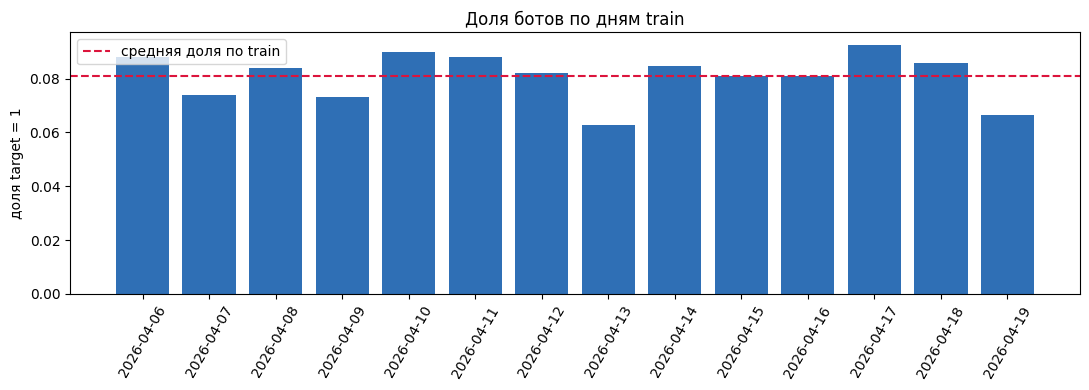

In [9]:
# Проверка 1: стабильна ли доля ботов по дням train.

day_stats = (
    train.assign(day=train["window_start_ts"].dt.date)
    .groupby("day")
    .agg(n_rows=("target", "size"), n_bots=("target", "sum"), bot_share=("target", "mean"))
    .reset_index()
)
day_stats["bot_share"] = day_stats["bot_share"].round(4)
print("Доля ботов по дням train:")
display(day_stats)
print("разброс доли ботов: от", day_stats["bot_share"].min(), "до", day_stats["bot_share"].max(),
      " (отношение max/min =", round(day_stats["bot_share"].max() / max(day_stats["bot_share"].min(), 1e-9), 2), ")")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([str(d) for d in day_stats["day"]], day_stats["bot_share"], color="#2f6fb5")
ax.axhline(train["target"].mean(), color="crimson", linestyle="--", label="средняя доля по train")
ax.set_ylabel("доля target = 1")
ax.set_title("Доля ботов по дням train")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

# Как читать: если доля ботов ровная, фолды на разных днях сопоставимы между собой и разброс метрики
# по фолдам говорит о модели. Если доля скачет в разы, часть разброса — это просто разные дни,
# и сравнивать фолды друг с другом бессмысленно.

In [10]:
# Проверка 2: adversarial validation. Учим модель отличать строку train от строки test.

Xadv = pd.concat([Xtr, Xte], ignore_index=True)
yadv = np.r_[np.zeros(len(Xtr), dtype=int), np.ones(len(Xte), dtype=int)]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_adv = np.zeros(len(Xadv))

for tr_idx, va_idx in tqdm(list(skf.split(Xadv, yadv)), desc="adversarial CV"):
    m = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        device=DEVICE, tree_method="hist",
        eval_metric="logloss", random_state=SEED, verbosity=0,
    )
    m.fit(Xadv.iloc[tr_idx], yadv[tr_idx])
    oof_adv[va_idx] = m.predict_proba(Xadv.iloc[va_idx])[:, 1]

adv_auc = roc_auc_score(yadv, oof_adv)
print(f"ROC-AUC 'train против test' на out-of-fold предсказаниях: {adv_auc:.4f}")

adv_full = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    device=DEVICE, tree_method="hist",
    eval_metric="logloss", random_state=SEED, verbosity=0,
)
adv_full.fit(Xadv, yadv)

imp = pd.Series(adv_full.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\nТоп-15 признаков, по которым модель различает train и test:")
display(imp.head(15).to_frame("важность"))

# Правило чтения:
#   AUC ~ 0.5   — распределения признаков в train и test совпадают, отличить нельзя.
#                 Значит случайный KFold честен, и можно пользоваться менее шумным протоколом.
#   AUC > 0.65  — сдвиг есть, модель видит разницу между периодами. Тогда список важностей выше
#                 показывает, какие именно признаки этот сдвиг создают. Главный подозреваемый —
#                 cookie_age_days: тест позже по календарю, поэтому куки там механически старше.

adversarial CV:   0%|          | 0/5 [00:00<?, ?it/s]

ROC-AUC 'train против test' на out-of-fold предсказаниях: 0.5145

Топ-15 признаков, по которым модель различает train и test:


,важность
window_dow,0.039499
n_user_agent,0.033992
ptr_x_nunique,0.033121
dt_frac_lt_1s,0.032491
mean_search_page,0.031575
contact_per_view,0.031543
cnt_search_results_view,0.031536
n_active_hours,0.031246
dt_std,0.031183
span_seconds,0.031103


## Как читать результат предыдущей ячейки

Adversarial AUC — это ответ на вопрос «отличается ли тестовый период от обучающего по тем признакам,
которыми мы пользуемся». Дальше возможны два сценария, и оба заранее описаны, чтобы после запуска не
подгонять интерпретацию под полученное число.

**Сценарий А — дрейфа нет (AUC близко к 0.5).** Значит признаки в тесте выглядят так же, как в трейне, и
перемешивание строк ничего не искажает. Тогда **основным протоколом становится случайный** (повторённый
стратифицированный KFold): в нём валидация покрывает все строки и повторяется трижды, а значит оценка
метрики заметно менее шумная. Временной сплит при этом никуда не девается — он остаётся **страховкой**:
если какое-то изменение резко улучшает случайную оценку и одновременно ухудшает временную, это повод
насторожиться, а не радоваться.

**Сценарий Б — дрейф есть (AUC заметно выше 0.65).** Тогда случайной оценке верить нельзя: она меряет
качество на популяции, которой в тесте не будет. Основным становится **временной протокол**, и отдельно
надо разобраться с признаками из верхушки списка важностей. Для `cookie_age_days` лечение очевидное:
либо убрать признак, либо заменить его на что-то, не зависящее от абсолютного календаря. Смотреть при
этом надо не только на AUC, но и на то, что будет с качеством после удаления — если признак полезен и
сдвиг небольшой, иногда разумнее оставить его и просто не доверять случайной валидации.

Промежуточный случай (AUC порядка 0.55-0.65) трактуем в сторону осторожности: основным считаем временной
протокол, случайный держим рядом как менее шумный ориентир и требуем, чтобы улучшения были видны в обоих.

In [11]:
# Два набора фолдов: временной (расширяющееся окно) и случайный.

D = lambda s: pd.Timestamp(s)

# Схема временных фолдов: обучаемся на прошлом, проверяемся на будущем.
# Каждая следующая тренировка включает предыдущую валидацию — «расширяющееся окно».
TIME_FOLD_SPEC = [
    # (имя, начало train, конец train включительно, начало valid, конец valid включительно)
    ("time_f1", "2026-04-06", "2026-04-13", "2026-04-14", "2026-04-15"),
    ("time_f2", "2026-04-06", "2026-04-15", "2026-04-16", "2026-04-17"),
    ("time_f3", "2026-04-06", "2026-04-17", "2026-04-18", "2026-04-19"),
]

# «Большой» фолд держим ОТДЕЛЬНО, а не в общем списке. Причина: его валидация (13-19)
# накрывает валидации всех трёх фолдов выше. Если сложить их в один OOF-вектор, то у части
# строк предсказание окажется средним от моделей, обученных на разном объёме данных, и
# полученное число будет ни тем ни другим. Поэтому большой фолд считаем как самостоятельную
# проверку: одна модель, обучение 7 дней, валидация ровно 7 дней — как на тесте.
BIG_FOLD_SPEC = [
    ("time_big", "2026-04-06", "2026-04-12", "2026-04-13", "2026-04-19"),
]

TIME_FOLD_NAMES = [s[0] for s in TIME_FOLD_SPEC]
BIG_FOLD_NAMES = [s[0] for s in BIG_FOLD_SPEC]


def make_time_folds(meta, spec):
    """Список пар (train_idx, valid_idx) по описанию границ дней."""
    day = meta["window_start_ts"].dt.normalize()
    folds = []
    for _, tr_a, tr_b, va_a, va_b in spec:
        tr_mask = (day >= D(tr_a)) & (day <= D(tr_b))
        va_mask = (day >= D(va_a)) & (day <= D(va_b))
        folds.append((np.where(tr_mask.values)[0], np.where(va_mask.values)[0]))
    return folds


time_folds = make_time_folds(train, TIME_FOLD_SPEC)
big_folds = make_time_folds(train, BIG_FOLD_SPEC)

# Случайный протокол: 5 частей, повторённых 3 раза с разным перемешиванием.
# Три повтора нужны, чтобы оценка меньше зависела от одного конкретного разбиения.
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
rand_folds = list(rskf.split(Xtr, ytr))
RAND_FOLD_NAMES = [f"rand_r{i // 5 + 1}_f{i % 5 + 1}" for i in range(len(rand_folds))]

rows = []
for proto, names, folds in [("временной", TIME_FOLD_NAMES, time_folds),
                            ("большой", BIG_FOLD_NAMES, big_folds),
                            ("случайный", RAND_FOLD_NAMES, rand_folds)]:
    for nm, (tr_idx, va_idx) in zip(names, folds):
        rows.append({"протокол": proto, "фолд": nm, "n_train": len(tr_idx),
                     "n_valid": len(va_idx), "ботов в valid": int(ytr[va_idx].sum()),
                     "доля ботов в valid": round(float(ytr[va_idx].mean()), 4)})

folds_table = pd.DataFrame(rows)
print("Состав фолдов:")
display(folds_table)

# Сколько строк временной протокол вообще не оценивает: первые дни всегда только обучающие.
never_valid = len(train) - len(set(np.concatenate([va for _, va in time_folds])))
print("\nстрок train, которые НИ РАЗУ не попадают в valid временного протокола:", never_valid)
print("именно поэтому его OOF короче, чем у случайного, и числа двух протоколов")
print("нельзя сравнивать не глядя на колонку «строк в OOF».")

Состав фолдов:


,протокол,фолд,n_train,n_valid,ботов в valid,доля ботов в valid
0,временной,time_f1,6773,1627,135,0.0830
1,временной,time_f2,8400,1453,126,0.0867
2,временной,time_f3,9853,1238,94,0.0759
3,большой,time_big,5930,5161,408,0.0791
4,случайный,rand_r1_f1,8872,2219,180,0.0811
5,случайный,rand_r1_f2,8873,2218,179,0.0807
6,случайный,rand_r1_f3,8873,2218,180,0.0812
7,случайный,rand_r1_f4,8873,2218,180,0.0812
8,случайный,rand_r1_f5,8873,2218,180,0.0812
9,случайный,rand_r2_f1,8872,2219,180,0.0811



строк train, которые НИ РАЗУ не попадают в valid временного протокола: 6773
именно поэтому его OOF короче, чем у случайного, и числа двух протоколов
нельзя сравнивать не глядя на колонку «строк в OOF».


In [12]:
# Фабрики моделей и универсальный прогон кросс-валидации.

# Про баланс классов: scale_pos_weight и class_weight мы СОЗНАТЕЛЬНО не выставляем.
# Метрика ранговая — она смотрит только на порядок кук по score, а не на абсолютные вероятности.
# Перевес положительного класса растягивает вероятности, но почти не меняет порядок,
# зато добавляет ещё один непроверенный параметр. На этапе настройки протокола это лишнее.

def make_xgb():
    return XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        device=DEVICE, tree_method="hist",
        eval_metric="logloss", random_state=SEED, verbosity=0, n_jobs=-1,
    )


def make_lgbm():
    # LightGBM держим всегда на процессоре: колёса с pypi собираются без поддержки GPU,
    # указание device="gpu" там просто упадёт. Это не ошибка настройки, а свойство сборки.
    return LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1, verbose=-1,
    )


def make_cat():
    return CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        rsm=0.8, random_seed=SEED, verbose=0,
        task_type="GPU" if DEVICE == "cuda" else "CPU",
    )


def run_cv(make_model, X, y, folds, name, fold_names=None):
    """Прогоняет кросс-валидацию и возвращает (oof, per_fold, summary).

    На каждом фолде обучается СВЕЖАЯ модель — дообучения между фолдами нет.
    oof: вектор длины len(y). Строки, которые ни разу не были в валидации, остаются NaN.
    Если строка попадает в валидацию несколько раз (повторы KFold), предсказания усредняются.
    """
    y = np.asarray(y)
    acc = np.zeros(len(y))     # сумма предсказаний
    cnt = np.zeros(len(y))     # сколько раз строка была в валидации
    per_fold = []
    if fold_names is None:
        fold_names = [f"fold{i + 1}" for i in range(len(folds))]

    pbar = tqdm(list(zip(fold_names, folds)), desc=f"CV {name}")
    for fname, (tr_idx, va_idx) in pbar:
        t0 = time.time()
        model = make_model()
        model.fit(X.iloc[tr_idx], y[tr_idx])
        p = model.predict_proba(X.iloc[va_idx])[:, 1]
        acc[va_idx] += p
        cnt[va_idx] += 1
        score = precision_at_recall(y[va_idx], p)
        per_fold.append({"фолд": fname, "P@R>=0.70": score,
                         "n_valid": len(va_idx), "ботов": int(y[va_idx].sum())})
        pbar.set_postfix({"фолд": fname, "P@R": f"{score:.4f}", "сек": f"{time.time() - t0:.1f}"})

    oof = np.full(len(y), np.nan)
    seen = cnt > 0
    oof[seen] = acc[seen] / cnt[seen]

    pf = pd.DataFrame(per_fold)
    summary = {
        "протокол": name,
        "P@R per-fold mean": float(pf["P@R>=0.70"].mean()),
        "P@R per-fold std": float(pf["P@R>=0.70"].std(ddof=1)) if len(pf) > 1 else np.nan,
        "P@R pooled OOF": float(precision_at_recall(y[seen], oof[seen])),
        "ROC-AUC": float(roc_auc_score(y[seen], oof[seen])),
        "PR-AUC": float(average_precision_score(y[seen], oof[seen])),
        "recall@fpr=1%": float(recall_at_fpr(y[seen], oof[seen], 0.01)),
        "строк в OOF": int(seen.sum()),
    }
    return oof, pf, summary

In [13]:
# Прогоняем один и тот же XGBoost по всем протоколам и сравниваем числа.

oof_time, pf_time, sum_time = run_cv(make_xgb, Xtr, ytr, time_folds, "временной", TIME_FOLD_NAMES)
oof_big, pf_big, sum_big = run_cv(make_xgb, Xtr, ytr, big_folds, "большой (7 дней)", BIG_FOLD_NAMES)
oof_rand, pf_rand, sum_rand = run_cv(make_xgb, Xtr, ytr, rand_folds, "случайный", RAND_FOLD_NAMES)

print("\nМетрика по каждому фолду — временной протокол:")
display(pf_time)
print("Метрика по каждому фолду — случайный протокол:")
display(pf_rand)

compare = pd.DataFrame([sum_time, sum_big, sum_rand]).set_index("протокол")
compare = compare[["P@R per-fold mean", "P@R per-fold std", "P@R pooled OOF",
                   "ROC-AUC", "PR-AUC", "recall@fpr=1%", "строк в OOF"]]
print("\nСводка по протоколам:")
display(compare.round(4))

# Как это читать.
#
# 1) "per-fold mean" и "pooled OOF" — это ДВА РАЗНЫХ числа, и путать их нельзя.
#    per-fold mean — метрика считается отдельно внутри каждого фолда и потом усредняется.
#                    Каждый фолд маленький, поэтому оценка шумная, зато её разброс (std)
#                    прямо показывает, насколько модель устойчива от фолда к фолду.
#    pooled OOF    — все предсказания складываются в один вектор, и метрика считается один раз
#                    по нему. Это ближе по размеру к тому, что будет на тесте, и стабильнее.
#    Основное решение принимаем по pooled OOF, per-fold std держим как индикатор устойчивости.
#
# 2) У строки "большой (7 дней)" фолд ровно один, поэтому std пустой, а per-fold mean и
#    pooled OOF совпадают. Это не ошибка: строка нужна как самая честная имитация теста —
#    учимся на неделе, проверяемся на следующей неделе.
#
# 3) Если временной и случайный протоколы дают близкие числа (разница меньше шума, который
#    мы померим в следующей ячейке), значит сдвига во времени нет и дальше можно работать
#    по случайному — он менее шумный. Если расходятся — верим только временному.

CV временной:   0%|          | 0/3 [00:00<?, ?it/s]

CV большой (7 дней):   0%|          | 0/1 [00:00<?, ?it/s]

CV случайный:   0%|          | 0/15 [00:00<?, ?it/s]


Метрика по каждому фолду — временной протокол:


,фолд,P@R>=0.70,n_valid,ботов
0,time_f1,0.428571,1627,135
1,time_f2,0.402715,1453,126
2,time_f3,0.594595,1238,94


Метрика по каждому фолду — случайный протокол:


,фолд,P@R>=0.70,n_valid,ботов
0,rand_r1_f1,0.461818,2219,180
1,rand_r1_f2,0.475472,2218,179
2,rand_r1_f3,0.602871,2218,180
3,rand_r1_f4,0.443662,2218,180
4,rand_r1_f5,0.510121,2218,180
5,rand_r2_f1,0.583333,2219,180
6,rand_r2_f2,0.436860,2218,179
7,rand_r2_f3,0.379518,2218,180
8,rand_r2_f4,0.453237,2218,180
9,rand_r2_f5,0.496063,2218,180



Сводка по протоколам:


,P@R per-fold mean,P@R per-fold std,P@R pooled OOF,ROC-AUC,PR-AUC,recall@fpr=1%,строк в OOF
протокол,,,,,,,
временной,0.4753,0.1041,0.4611,0.8854,0.6852,0.5042,4318
большой (7 дней),0.3972,NaN,0.3972,0.8806,0.6664,0.5049,5161
случайный,0.4800,0.0582,0.5004,0.8946,0.7062,0.5451,11091


строк в OOF случайного протокола: 11091  из них ботов: 899


bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]


Распределение метрики при пересборе валидации:


,значение
метрика на полной OOF,0.5004
bootstrap среднее,0.5001
bootstrap std,0.0410
перцентиль 5%,0.4367
перцентиль 95%,0.5720
ширина интервала 5-95%,0.1353


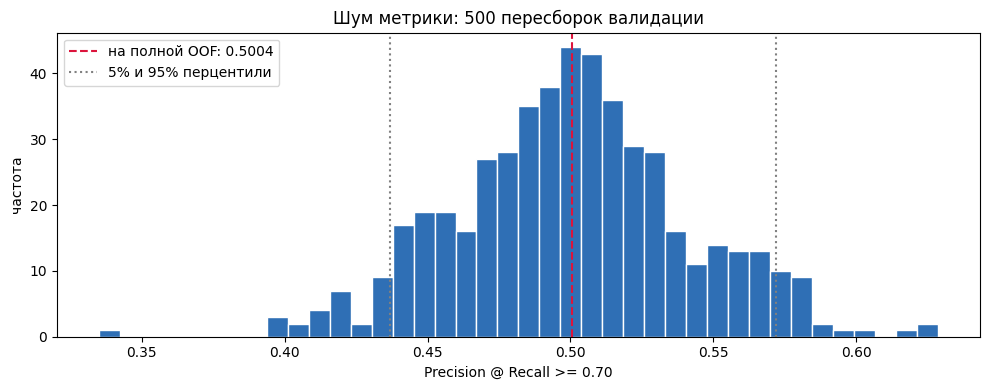


  ЭТО ЦЕНА ДЕЛЕНИЯ.
  std метрики от одного лишь состава валидации: 0.0410
  Улучшение меньше одного std неотличимо от случайного колебания:
  на него нельзя принимать решения и тем более тратить одну из 7 отправок.
  Значимым считаем изменение хотя бы в 2 std, и желательно подтверждённое
  обоими протоколами сразу.


In [14]:
# Сколько стоит одно деление шкалы: bootstrap шума метрики.
# Модель и предсказания фиксированы — мы меняем ТОЛЬКО состав валидационной выборки,
# пересобирая её из тех же строк с возвращением. Весь разброс, который получится, —
# это чистый шум от того, какие именно куки попали в оценку.

N_BOOT = 500
rng = np.random.default_rng(SEED)

mask = ~np.isnan(oof_rand)
s_oof = oof_rand[mask]
y_oof = ytr[mask]
n = len(s_oof)
print("строк в OOF случайного протокола:", n, " из них ботов:", int(y_oof.sum()))

boot = np.empty(N_BOOT)
for i in tqdm(range(N_BOOT), desc="bootstrap"):
    idx = rng.integers(0, n, size=n)
    boot[i] = precision_at_recall(y_oof[idx], s_oof[idx])

base = precision_at_recall(y_oof, s_oof)
boot_stats = pd.Series({
    "метрика на полной OOF": base,
    "bootstrap среднее": boot.mean(),
    "bootstrap std": boot.std(ddof=1),
    "перцентиль 5%": np.percentile(boot, 5),
    "перцентиль 95%": np.percentile(boot, 95),
    "ширина интервала 5-95%": np.percentile(boot, 95) - np.percentile(boot, 5),
}).round(4)
print("\nРаспределение метрики при пересборе валидации:")
display(boot_stats.to_frame("значение"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot, bins=40, color="#2f6fb5", edgecolor="white")
ax.axvline(base, color="crimson", linestyle="--", label=f"на полной OOF: {base:.4f}")
ax.axvline(np.percentile(boot, 5), color="gray", linestyle=":", label="5% и 95% перцентили")
ax.axvline(np.percentile(boot, 95), color="gray", linestyle=":")
ax.set_xlabel("Precision @ Recall >= 0.70")
ax.set_ylabel("частота")
ax.set_title(f"Шум метрики: {N_BOOT} пересборок валидации")
ax.legend()
plt.tight_layout()
plt.show()

print()
print("=" * 78)
print("  ЭТО ЦЕНА ДЕЛЕНИЯ.")
print(f"  std метрики от одного лишь состава валидации: {boot.std(ddof=1):.4f}")
print("  Улучшение меньше одного std неотличимо от случайного колебания:")
print("  на него нельзя принимать решения и тем более тратить одну из 7 отправок.")
print("  Значимым считаем изменение хотя бы в 2 std, и желательно подтверждённое")
print("  обоими протоколами сразу.")
print("=" * 78)

In [15]:
# Диагностика ties: не выдаёт ли модель плато из одинаковых score.
# Метрика обрабатывает равные score одной группой: либо через порог проходит вся группа, либо никто.
# Если у порога стоит большая группа с одинаковым значением, precision может обвалиться разом.

prec, rec = pr_curve(y_oof, s_oof)

# те же точки, что считает pr_curve, но нам нужны сами пороги
order = np.argsort(-s_oof, kind="mergesort")
s_sorted = s_oof[order]
ends = np.r_[s_sorted[1:] != s_sorted[:-1], True]
thresholds = s_sorted[ends]

ok = rec >= 0.70
if not ok.any():
    print("recall 0.70 не достигается ни на одном пороге — проверьте предсказания")
else:
    best_local = int(np.argmax(prec[ok]))
    best_pos = int(np.where(ok)[0][best_local])
    thr = float(thresholds[best_pos])
    print("Рабочая точка (там, где метрика достигает максимума при recall >= 0.70):")
    print(f"   порог score      = {thr:.8f}")
    print(f"   precision        = {prec[best_pos]:.4f}")
    print(f"   recall           = {rec[best_pos]:.4f}")
    print(f"   отмечено кук     = {(s_oof >= thr).sum()} из {len(s_oof)}")

    # сколько строк имеют РОВНО этот score — это и есть группа, проходящая через порог целиком
    tie_at_thr = int((s_oof == thr).sum())
    print(f"\nстрок ровно с этим score (одна неделимая группа): {tie_at_thr}")

    # что происходит в окрестности порога
    vals, counts = np.unique(s_oof, return_counts=True)
    near = np.abs(vals - thr) <= 1e-6
    print(f"различных значений score в окрестности +-1e-6 от порога: {int(near.sum())},"
          f" строк в них: {int(counts[near].sum())}")

    grp = pd.DataFrame({"score": vals, "строк с таким score": counts})
    biggest = grp.sort_values("строк с таким score", ascending=False).head(10)
    print("\nСамые большие группы одинаковых score во всей OOF:")
    display(biggest.reset_index(drop=True))
    print("максимальный размер группы равных score:", int(counts.max()),
          f"({counts.max() / len(s_oof):.2%} всех строк)")
    print("доля строк, чей score не уникален:",
          f"{counts[counts > 1].sum() / len(s_oof):.2%}")

# Как читать: если максимальная группа — единицы строк, ties не проблема, вещественные
# предсказания бустинга и так почти всегда различны. Если же видно плато в сотни строк
# (обычно это куки вообще без событий, у которых все признаки одинаковы), то такая группа
# проходит порог целиком и может резко уронить precision. Тогда на следующем этапе понадобится
# tiebreaker — крошечная добавка к score, разводящая равные значения по осмысленному признаку.

Рабочая точка (там, где метрика достигает максимума при recall >= 0.70):
   порог score      = 0.08009417
   precision        = 0.5004
   recall           = 0.7008
   отмечено кук     = 1259 из 11091

строк ровно с этим score (одна неделимая группа): 1
различных значений score в окрестности +-1e-6 от порога: 1, строк в них: 1

Самые большие группы одинаковых score во всей OOF:


,score,строк с таким score
0,0.000047,1
1,0.012894,1
2,0.012853,1
3,0.012857,1
4,0.012859,1
5,0.012860,1
6,0.012862,1
7,0.012871,1
8,0.012873,1
9,0.012890,1


максимальный размер группы равных score: 1 (0.01% всех строк)
доля строк, чей score не уникален: 0.00%


## Итог этапа 1

Что измерено и какие решения на этом висят. Числа сюда вписываются **после запуска ноутбука** —
выдумывать их заранее нельзя, в этом и был смысл всего этапа.

| что измерено | где смотреть | значение | какое решение зависит |
|---|---|---|---|
| Доля событий вне окна | ячейка 4 | 12.4% (все — после конца окна) | фильтр `[start, end)` обязателен |
| Капча: доля у ботов / у людей | ячейка 5 | ~49% / ~1.3% | `captcha_shown` не используем, это будущее |
| Разброс доли ботов по дням | ячейка 13 | _заполнить_ | сопоставимы ли фолды между собой |
| Adversarial AUC train vs test | ячейка 14 | _заполнить_ | **какой протокол основной** |
| P@R pooled OOF, временной | ячейка 18 | _заполнить_ | базовая точка отсчёта |
| P@R pooled OOF, случайный | ячейка 18 | _заполнить_ | базовая точка отсчёта |
| Расхождение двух протоколов | ячейка 18 | _заполнить_ | верим ли менее шумной оценке |
| **Цена деления (bootstrap std)** | ячейка 19 | _заполнить_ | **порог значимости улучшений** |
| Максимальная группа равных score | ячейка 20 | _заполнить_ | нужен ли tiebreaker |

Вопросы, на которые ответ даст запуск:

1. **Какой протокол основной?** Если adversarial AUC около 0.5 — основным берём случайный
   (он менее шумный), временной оставляем страховкой. Если заметно выше — основным становится временной,
   а признаки из верхушки важностей (прежде всего `cookie_age_days`) разбираем отдельно.
2. **Какова цена деления?** Bootstrap std из ячейки 19. Всё, что меньше одного std, — шум. Значимым
   считаем изменение от двух std. Это правило прямо экономит отправки: их всего 7.
3. **Есть ли проблема ties?** Если в OOF нашлось плато в сотни строк с одинаковым score, на следующем
   этапе нужен tiebreaker.

### План следующего этапа

1. **Полный feature engineering.** Разбиение активности на сессии (пауза больше N минут — новая сессия) и
   признаки по сессиям. Регулярность интервалов между действиями — насколько ритм машинный. Разбор
   `user_agent` на составляющие (движок, ОС, версия) и частотное кодирование — по фактам из EDA,
   у клиентов вроде Scrapy, curl, node-fetch доля ботов 25-33% при базе 8%, то есть это сильный признак,
   но не детерминированный флаг, и в модели он должен работать вместе с остальными. Глубина и повторяемость
   поисковых запросов, покрытие категорий и городов, признаки курсора подробнее (шаги между точками,
   доля повторяющихся координат).
2. **Проверка каждого блока признаков по выбранному протоколу** с обязательным сравнением прироста с
   ценой деления — без этого улучшения нельзя отличить от шума.
3. **Сравнение трёх бустингов** (XGBoost, LightGBM, CatBoost) на одинаковых фолдах и усреднение рангов,
   если они дают некоррелированные ошибки.
4. **Tiebreaker**, если ячейка 20 покажет крупные группы равных score.
5. **Сборка сабмита**: обучение на всём train, предсказание на test, запись `cookie_id, score`.

## Финальная модель и сборка сабмита

**Первая отправка сознательно делается на текущей модели из 33 признаков.** Её задача — не выжать
максимум, а связать локальную оценку с лидербордом. Локально мы намерили P@R = 0.5004 при разбросе
0.041, и по тому, насколько LB разойдётся с этим числом, поймём, честна ли наша валидация. Если сразу
менять модель и одновременно смотреть на LB, потом будет не разобрать, что на что повлияло.

**Финальная модель обучается на всех 11091 строках train** — теми же гиперпараметрами, которые
проверялись на кросс-валидации. Ничего не подкручиваем: иначе отправим не ту модель, качество которой
измеряли, и расхождение с лидербордом будет нечем объяснить. Разбиение на фолды здесь уже не нужно —
фолды были нужны, чтобы ИЗМЕРИТЬ качество, а для отправки мы хотим модель, видевшую все размеченные
данные целиком.

**Отправляем только score, порог не наш.** Метрика ранговая, и порог проверяющая система подбирает
сама. Значит, калибровать числа, подгонять их под долю ботов или округлять смысла нет — результат
определяет только ПОРЯДОК кук по score.

**Попыток на конкурс всего 7, эта — первая.**

In [16]:
# Финальная модель. Фолдов здесь больше нет: кросс-валидация была нужна, чтобы измерить качество,
# а для отправки мы хотим модель, которая увидела максимум размеченных данных.
# Гиперпараметры берём из make_xgb() без единого изменения — ровно те, что крутились на CV.

t0 = time.time()
model = make_xgb()
model.fit(Xtr[FEATURES], ytr)
fit_sec = time.time() - t0

print(f"обучено на всём train: {len(Xtr)} строк, {len(FEATURES)} признаков")
print(f"время обучения: {fit_sec:.1f} сек (устройство: {DEVICE})")

# predict_proba возвращает два столбца — вероятность «не бот» и «бот». Нам нужен второй:
# именно это число уедет в сабмит и по нему проверяющая система будет ранжировать куки.
pred = model.predict_proba(Xte[FEATURES])[:, 1]
print("получено предсказаний:", pred.shape[0])

# Смотрим на распределение, чтобы поймать грубую ошибку до отправки: числа обязаны лежать
# в [0, 1], не слипаться в одну точку, а средний score — быть в районе доли ботов в train (0.0811).
print("\nраспределение score по test:")
print(pd.Series(pred, name="score").describe())
print("\nсредний score по test:", round(float(pred.mean()), 4), " | доля ботов в train: 0.0811")

# Важности признаков — не доказательство, а быстрая проверка на здравый смысл:
# если наверху окажется что-то бессмысленное, лучше заметить это сейчас.
imp = (
    pd.DataFrame({"признак": FEATURES, "важность": model.feature_importances_})
    .sort_values("важность", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("\nтоп-10 признаков финальной модели:")
display(imp)

обучено на всём train: 11091 строк, 33 признаков
время обучения: 1.7 сек (устройство: cuda)
получено предсказаний: 4909

распределение score по test:
count    4909.000000
mean        0.069942
std         0.197921
min         0.000051
25%         0.002079
50%         0.006637
75%         0.025375
max         0.999663
Name: score, dtype: float64

средний score по test: 0.0699  | доля ботов в train: 0.0811

топ-10 признаков финальной модели:


,признак,важность
0,n_cat_uniq,0.094128
1,dt_median,0.081369
2,n_loc_uniq,0.058995
3,max_search_page,0.044633
4,n_events,0.042318
5,cnt_favorite_add,0.035141
6,contact_per_view,0.032392
7,events_per_hour,0.031909
8,dt_min,0.031111
9,cnt_item_view,0.028663


In [17]:
# Порядок строк в сабмите — это требование формата, а не косметика.
# Проверяющая система ждёт cookie_id ровно в том порядке, в котором они лежат
# в sample_submission.csv. Файл из quickstart этому не соответствовал: он собирался
# в порядке строк test.csv, а этот порядок другой.
# Поэтому мы ничего не сортируем, а именно переставляем свои строки под эталонный список.

SAMPLE_PATH = Path("sample_submission.csv")   # лежит в корне проекта, а не в data/
sample = pd.read_csv(SAMPLE_PATH)
print("эталон формата:", sample.shape, list(sample.columns))

# Привязываем предсказания к кукам теста. Порядок строк Xte совпадает с порядком test —
# это мы проверяли assert'ом ещё при сборке признаков.
pred_by_cookie = pd.DataFrame({"cookie_id": test["cookie_id"].values, "score": pred})

# reindex по списку кук из эталона: строки встают в нужный порядок, а если какой-то куки
# у нас вдруг не найдётся, на её месте окажется NaN — и следующая ячейка это поймает.
submission = (
    pred_by_cookie
    .set_index("cookie_id")
    .reindex(sample["cookie_id"])
    .reset_index()
)
submission = submission[["cookie_id", "score"]]

print("\nсабмит собран:", submission.shape)
print("\nпервые строки:")
display(submission.head(10))

эталон формата: (4909, 2) ['cookie_id', 'score']

сабмит собран: (4909, 2)

первые строки:


,cookie_id,score
0,ck_99a4e5ef02d89493,0.006700
1,ck_54d463f7fd89ec3d,0.008926
2,ck_0fbbc7a6af300368,0.005519
3,ck_8fd4937eadd64fb6,0.078461
4,ck_dbb4bd4eda97255d,0.003919
5,ck_6e67225ba59fa5ae,0.062104
6,ck_94b59bbc824b307a,0.000510
7,ck_b87e88ee5512ea17,0.000695
8,ck_36789ca11459131e,0.006156
9,ck_4364a83a11743888,0.000614


In [18]:
# Проверки формата. Все через assert: молча испорченный файл стоит целой попытки,
# а попыток всего 7. Пусть лучше ноутбук упадёт здесь, чем мы потратим отправку впустую.

# 1. Ровно столько строк, сколько кук в тесте.
assert len(submission) == 4909, f"строк {len(submission)}, а ожидали 4909"
assert len(submission) == len(test), "число строк не совпадает с test"
print("строк:", len(submission), "— ок")

# 2. Ровно две колонки и именно в таком порядке.
assert list(submission.columns) == ["cookie_id", "score"], list(submission.columns)
print("колонки:", list(submission.columns), "— ок")

# 3. Ни одна кука не встречается дважды.
assert submission["cookie_id"].is_unique, "в сабмите есть повторяющиеся cookie_id"
print("дублей cookie_id нет — ок")

# 4. Ни одного пропуска. NaN в score означал бы, что для куки не нашлось предсказания.
assert submission["cookie_id"].notna().all(), "есть пустые cookie_id"
n_nan = int(submission["score"].isna().sum())
assert n_nan == 0, f"пустых score: {n_nan}"
print("пропусков нет ни в одной колонке — ок")

# 5. Набор кук совпадает с test.csv: ни одной лишней, ни одной потерянной.
set_sub = set(submission["cookie_id"])
set_test = set(test["cookie_id"])
assert set_sub == set_test, f"лишних кук: {len(set_sub - set_test)}, потеряно: {len(set_test - set_sub)}"
print("набор cookie_id совпадает с test.csv — ок")

# 6. Порядок совпадает с эталоном строка в строку.
assert submission["cookie_id"].tolist() == sample["cookie_id"].tolist(), \
    "порядок cookie_id не совпадает с sample_submission.csv"
print("порядок cookie_id побайтово совпадает с sample_submission.csv — ок")

# 7. score — это вероятности, значит всё должно лежать в [0, 1].
s_min = float(submission["score"].min())
s_max = float(submission["score"].max())
assert s_min >= 0.0 and s_max <= 1.0, f"score вышел за [0, 1]: [{s_min}, {s_max}]"
print(f"score в диапазоне [{s_min:.6f}, {s_max:.6f}] — ок")

# 8. Диагностика ties. Метрика обрабатывает одинаковые score одной группой: через порог
# проходит либо вся группа целиком, либо никто. Большая группа у порога роняет precision разом.
vals, counts = np.unique(submission["score"].values, return_counts=True)
max_group = int(counts.max())
dup_share = float(counts[counts > 1].sum()) / len(submission)
print(f"\nties: максимальная группа одинаковых score = {max_group} строк"
      f" ({max_group / len(submission):.2%} сабмита)")
print(f"доля строк, чей score не уникален: {dup_share:.2%}")
if max_group > 50:
    print("группа крупная — на следующих попытках имеет смысл подумать о tiebreaker")

# Все проверки прошли — только теперь пишем файл.
# index=False, иначе в csv уедет лишний безымянный столбец с номерами строк.
SUB_PATH = Path("submission1.csv")
submission.to_csv(SUB_PATH, index=False)
size_kb = SUB_PATH.stat().st_size / 1024
print(f"\nсохранено: {SUB_PATH.resolve()}")
print(f"размер файла: {size_kb:.1f} КБ, строк с данными: {len(submission)}")
print("\nначало файла:")
print(SUB_PATH.read_text(encoding="utf-8")[:120])

строк: 4909 — ок
колонки: ['cookie_id', 'score'] — ок
дублей cookie_id нет — ок
пропусков нет ни в одной колонке — ок
набор cookie_id совпадает с test.csv — ок
порядок cookie_id побайтово совпадает с sample_submission.csv — ок
score в диапазоне [0.000051, 0.999663] — ок

ties: максимальная группа одинаковых score = 2 строк (0.04% сабмита)
доля строк, чей score не уникален: 0.12%

сохранено: C:\Users\user\PycharmProjects\ML Avito\submission1.csv
размер файла: 159.3 КБ, строк с данными: 4909

начало файла:
cookie_id,score
ck_99a4e5ef02d89493,0.006699971
ck_54d463f7fd89ec3d,0.008926144
ck_0fbbc7a6af300368,0.005518894
ck_8fd49


## Что ожидаем от этой отправки

Локально мы намерили **0.5004**, разброс валидации — **0.041**.

* Если LB попадёт примерно в **0.46–0.54**, валидация честная: локальные числа отражают реальность,
  и дальше можно спокойно проверять идеи у себя, не тратя попытки.
* Если LB окажется заметно ниже — значит, в валидации что-то не учтено. В этом случае нельзя
  бросаться улучшать модель: сначала надо найти причину расхождения, иначе мы будем улучшать
  локальное число, которое ничего не значит.

| Попытка | Что отправили | Локальный P@R | LB P@R | Вывод |
|---|---|---|---|---|
| 1 | XGBoost, 33 признака, обучен на всём train | 0.5004 | | |

(колонку **LB P@R** и **Вывод** заполняем руками после результата)

**Осталось 6 попыток.**